In [5]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw (1).csv to cars_hw (1) (1).csv


In [14]:
#Transform Variables
import pandas as pd

df = pd.read_csv("cars_hw (1).csv")

df = df.drop(columns=["Unnamed: 0"])
df["Car_Age"] = 2026 - df["Make_Year"]

y = df["Price"]

X = df.drop(columns=["Price"])
X = pd.get_dummies(X, drop_first=True)

In [16]:
#80/20 Train-test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#Linear Models

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model1 = LinearRegression()

features1 = ["Car_Age", "Mileage_Run"]

model1.fit(X_train[features1], y_train)

# Predictions
train_pred1 = model1.predict(X_train[features1])
test_pred1 = model1.predict(X_test[features1])

#Model 2
features2 = ["Car_Age", "Mileage_Run", "Seating_Capacity"]

model2 = LinearRegression()
model2.fit(X_train[features2], y_train)

train_pred2 = model2.predict(X_train[features2])
test_pred2 = model2.predict(X_test[features2])

#Model 3
model3 = LinearRegression()

model3.fit(X_train, y_train)

train_pred3 = model3.predict(X_train)
test_pred3 = model3.predict(X_test)

#Evaluate RMSE
def evaluate(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

results = []

for name, ytr, yte in [
    ("Model 1", train_pred1, test_pred1),
    ("Model 2", train_pred2, test_pred2),
    ("Model 3", train_pred3, test_pred3),
]:
    train_rmse, train_r2 = evaluate(y_train, ytr)
    test_rmse, test_r2 = evaluate(y_test, yte)

    results.append({
        "Model": name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results)
print(results_df)

     Model     Train RMSE      Test RMSE  Train R2   Test R2
0  Model 1  310695.036967  283873.728209  0.308418  0.297407
1  Model 2  309338.372957  284546.951907  0.314445  0.294070
2  Model 3  142114.260570  143575.196607  0.855306  0.820273


Model 1 performs poorly, with a high test RMSE and low R², indicating that age and mileage alone are not enough to explain variation in price. Model 2 improves slightly by including seating capacity, but still underfits the data. Model 3 performs the best, with the lowest test RMSE and highest test R², showing that including all available features significantly improves predictive performance. This suggests that car price depends on a combination of characteristics rather than just a few numeric variables.

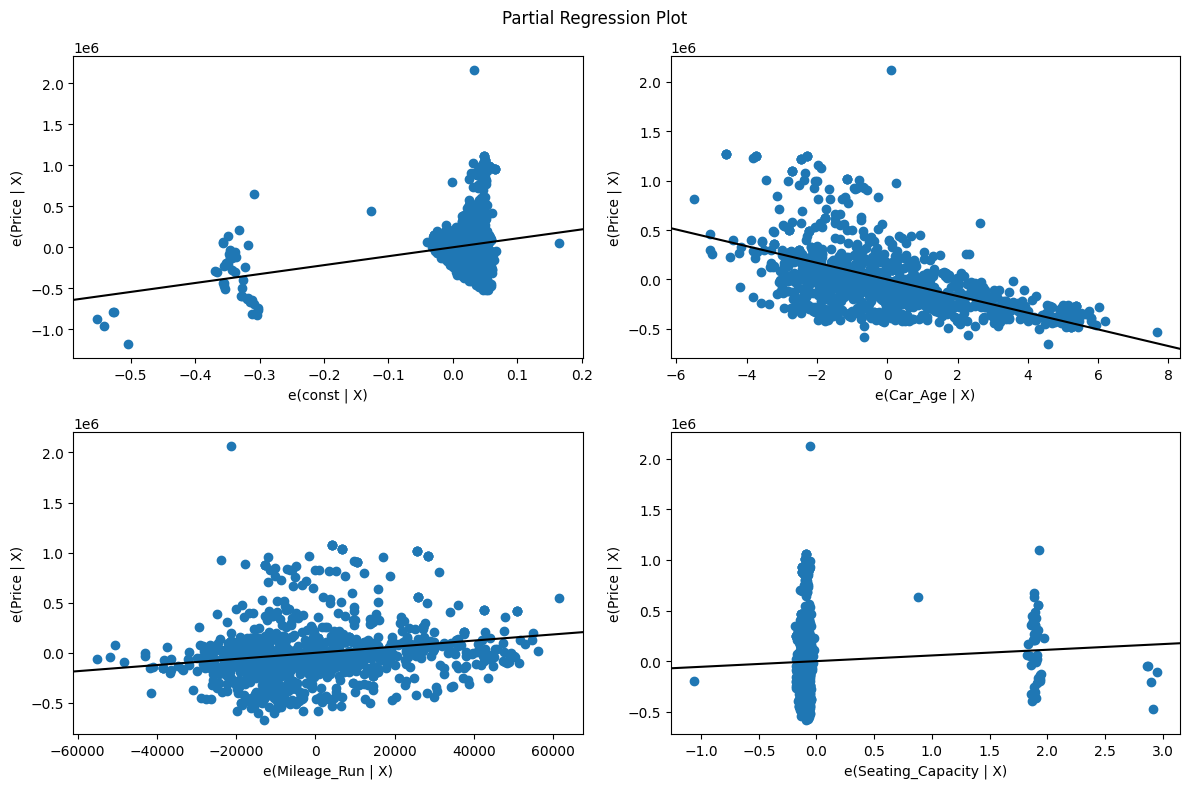

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
df = pd.read_csv("cars_hw (1).csv")

df = df.drop(columns=["Unnamed: 0"])
df["Car_Age"] = 2026 - df["Make_Year"]

numeric_vars = ["Car_Age", "Mileage_Run", "Seating_Capacity"]

X = df[numeric_vars]
y = df["Price"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
fig = plt.figure(figsize=(12, 8))

sm.graphics.plot_partregress_grid(model, fig=fig)

plt.tight_layout()
plt.show()

In [18]:
#Transformations
#Complex Model
import numpy as np

for data in [X_train, X_test]:
    data["log_mileage"] = np.log1p(data["Mileage_Run"])
    data["age2"] = data["Car_Age"] ** 2
    data["age_x_mileage"] = data["Car_Age"] * data["Mileage_Run"]

for data in [X_train, X_test]:
    if "Transmission_Type_Automatic" in data.columns:
        data["auto_x_mileage"] = data["Transmission_Type_Automatic"] * data["Mileage_Run"]
    if "Fuel_Type_diesel" in data.columns:
        data["diesel_x_mileage"] = data["Fuel_Type_diesel"] * data["Mileage_Run"]

#Fit Model
from sklearn.linear_model import LinearRegression

complex_model = LinearRegression()

complex_model.fit(X_train, y_train)

train_pred_c = complex_model.predict(X_train)
test_pred_c = complex_model.predict(X_test)

#Evaluate
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

train_rmse_c, train_r2_c = evaluate(y_train, train_pred_c)
test_rmse_c, test_r2_c = evaluate(y_test, test_pred_c)

print("Complex Model:")
print("Train RMSE:", train_rmse_c)
print("Test RMSE:", test_rmse_c)
print("Train R2:", train_r2_c)
print("Test R2:", test_r2_c)




Complex Model:
Train RMSE: 140760.27068147523
Test RMSE: 142490.6722575288
Train R2: 0.8580500854701555
Test R2: 0.8229782793294569


The more complex model improves upon the simpler models by incorporating non-linear transformations and interaction effects that  capture how car characteristics determine price.

Compared to the simpler models, the complex model achieves a lower test RMSE and higher test R², indicating improved predictive performance. This accounts for non-linearities.

The  models using only a few variables did not perform well, which shows underfitting because they were too basic. When more features were added, like fuel type and transmission, the model improved. After seeing  non-linear patterns, a more complex model with transformations and interactions was built, and it performed better on the test data.